# Day 4: Performance Analysis

This notebook analysis a Mutual Fund Performance Scorecard by analyzing historical Net Asset Value (NAV) data and comparing it against a market benchmark

# Section 1: Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

# Section 2: Load Data

In [2]:
nav = pd.read_csv("../data/processed/clean_02_nav_history.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
funds = pd.read_csv("../data/raw/01_fund_master.csv")

# Section 3: Data Preparation

In [3]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])
nav = nav.sort_values(
    ["amfi_code","date"]
)

# Section 4: Daily Returns

**Formula:**
$$\text{Return}_t = \frac{\text{NAV}_t}{\text{NAV}_{t-1}} - 1$$

In [4]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


### Check distribution:

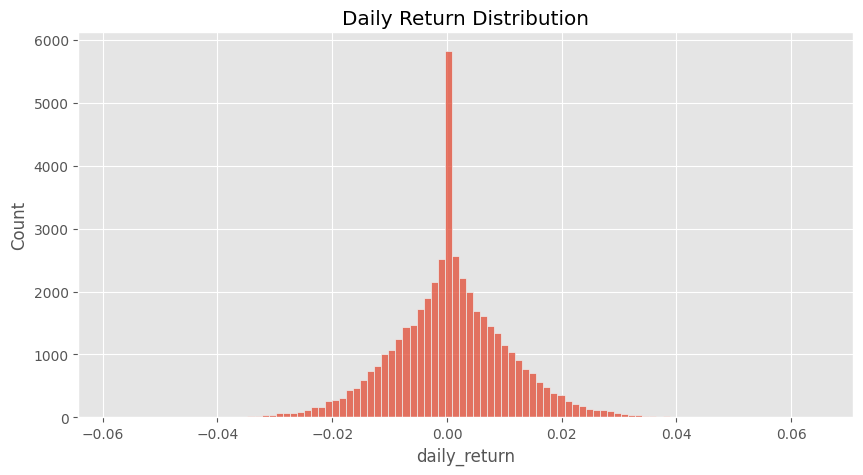

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title("Daily Return Distribution")
plt.savefig("../reports/performance/daily_return_distribution.png")
plt.show()

# Section 5: CAGR

**Function:**

In [21]:
def calculate_cagr(df, years):
    latest = df["date"].max()
    start  = latest - pd.DateOffset(years=years)
    temp   = df[df["date"] >= start].sort_values("date")   # ensure order

    if len(temp) < 2:
        return None

    start_nav = temp.iloc[0]["nav"]   # safe after sort
    end_nav   = temp.iloc[-1]["nav"]

    return (end_nav / start_nav) ** (1 / years) - 1


**Calculate:**

In [22]:
cagr_results = []
for code, grp in nav.groupby("amfi_code"):
    try:
        cagr_1 = calculate_cagr(grp, 1)
        cagr_3 = calculate_cagr(grp, 3)
        cagr_results.append([code, cagr_1, cagr_3])
    except Exception as e:
        print(f"Skipping {code}: {e}")   # visible, specific

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr_1y", "cagr_3y"]
)
cagr_df.head()


,amfi_code,cagr_1y,cagr_3y
0,100016,-0.022243,0.012926
1,100025,0.037050,0.039164
2,100033,0.532324,0.324425
3,101206,0.479241,0.289677
4,101207,-0.239860,-0.041524


# Section 6: Sharpe Ratio

In [27]:
RF = 0.065
sharpe_list = []

for code, grp in nav.groupby("amfi_code"):
    r = grp["daily_return"].dropna()
    
    annual_return = r.mean() * 252
    annual_vol = r.std() * np.sqrt(252)
    
    sharpe = (annual_return - RF) / annual_vol
    
    sharpe_list.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df = (
    sharpe_df
    .sort_values("sharpe_ratio", ascending=False)
    .reset_index(drop=True)
)
sharpe_df.index += 1          # rank starts at 1
sharpe_df.index.name = "rank"
print("Printing top 40 funds according to Sharpe_ratio")
sharpe_df.head(40)

Printing top 40 funds according to Sharpe_ratio


,amfi_code,sharpe_ratio
rank,,
1,148567,1.448291
2,120843,1.306744
3,148569,1.234930
4,119551,1.208267
5,120505,1.180101
6,149323,1.132122
7,100033,1.093699
8,118632,1.081659
9,101206,1.027213


# Section 7: Sortino Ratio

In [29]:
sortino_list = []

for code, grp in nav.groupby("amfi_code"):
    r = grp["daily_return"].dropna()
    
    downside = r[r < 0]
    annual_return = r.mean() * 252
    downside_std = downside.std() * np.sqrt(252)
    
    sortino = (annual_return - RF) / downside_std
    
    sortino_list.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


# Section 8: Alpha & Beta

Use NIFTY100.

In [11]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Daily benchmark returns
nifty100 = nifty100.sort_values("date")
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

### Calculate Alpha & Beta

In [12]:
alpha_beta = []

for code, grp in nav.groupby("amfi_code"):
    merged = pd.merge(
        grp,
        nifty100[["date", "benchmark_return"]],
        on="date"
    )
    
    merged = merged.dropna()
    
    if len(merged) < 50:
        continue
        
    beta, alpha, r, p, se = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )
    
    alpha_beta.append(
        [
            code,
            alpha * 252,
            beta
        ]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

# Section 9: Maximum Drawdown

In [32]:
drawdown_list = []
for code, grp in nav.groupby("amfi_code"):
    grp = grp.sort_values("date").copy()

    grp["running_max"] = grp["nav"].cummax()
    grp["drawdown"]    = (grp["nav"] / grp["running_max"]) - 1

    max_dd     = grp["drawdown"].min()
    trough_idx = grp["drawdown"].idxmin()

    # Peak is the last running_max before the trough
    peak_idx   = grp.loc[:trough_idx, "nav"].idxmax()

    drawdown_list.append([
        code,
        max_dd,
        grp.loc[peak_idx,   "date"],   # drawdown start (peak)
        grp.loc[trough_idx, "date"]    # drawdown end   (trough)
    ])

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=["amfi_code", "max_drawdown", "dd_start", "dd_end"]
)

drawdown_df.head()

,amfi_code,max_drawdown,dd_start,dd_end
0,100016,-0.247344,2022-03-30,2022-09-15
1,100025,-0.043083,2023-05-23,2023-07-28
2,100033,-0.162172,2022-03-11,2022-05-12
3,101206,-0.112916,2023-04-24,2023-07-05
4,101207,-0.354469,2024-11-21,2026-05-11


# Section 10: Tracking Error

In [34]:
tracking = []

for code, grp in nav.groupby("amfi_code"):
    merged = pd.merge(
        grp,
        nifty100[["date", "benchmark_return"]],
        on="date"
    )
    
    merged = merged.dropna()
    
    diff = (
        merged["daily_return"] - merged["benchmark_return"]
    )
    
    te = diff.std() * np.sqrt(252)
    
    tracking.append(
        [code, te]
    )

tracking_df = pd.DataFrame(
    tracking,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

# Section 11: Fund Scorecard

### Merge all metrics.

In [35]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    funds[
        ["amfi_code",
         "expense_ratio_pct",
         "scheme_name"]
    ],
    on="amfi_code"
)

### Ranking

In [36]:
n = len(scorecard)

# Higher metric = better rank → rank descending so rank 1 = best
scorecard["cagr_rank"]    = scorecard["cagr_3y"].rank(ascending=False)
scorecard["sharpe_rank"]  = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["alpha_rank"]   = scorecard["alpha"].rank(ascending=False)

# Lower metric = better → rank ascending so rank 1 = best
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)
scorecard["dd_rank"]      = scorecard["max_drawdown"].rank(ascending=True)  # dd is negative, so least negative = best... 

# ── drawdown fix ──────────────────────────────────────────────────────────────
# max_drawdown values are negative (e.g. -0.35). 
# ascending=True gives rank 1 to the most negative (worst). Need ascending=False.
scorecard["dd_rank"]      = scorecard["max_drawdown"].rank(ascending=False)

# Normalise each rank to 0–100  (rank 1 → 100, rank n → ~0)
for col in ["cagr_rank","sharpe_rank","alpha_rank","expense_rank","dd_rank"]:
    scorecard[col] = (n - scorecard[col]) / (n - 1) * 100


### Composite Score

In [37]:
scorecard["fund_score"] = (
      scorecard["cagr_rank"]   * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"]  * 0.20
    + scorecard["expense_rank"]* 0.15
    + scorecard["dd_rank"]     * 0.10
)

scorecard = scorecard.sort_values("fund_score", ascending=False).reset_index(drop=True)
scorecard.index += 1
scorecard.index.name = "rank"
scorecard.head(10)


,amfi_code,cagr_1y,cagr_3y,sharpe_ratio,alpha,beta,max_drawdown,dd_start,dd_end,expense_ratio_pct,scheme_name,cagr_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
rank,,,,,,,,,,,,,,,,,
1,148567,0.203607,0.340009,1.448291,0.269838,0.023684,-0.112657,2023-07-11,2023-10-20,1.46,Mirae Asset Large Cap Fund - Regular - Growth,97.435897,100.000000,84.615385,43.589744,82.051282,85.897436
2,120505,0.296047,0.317775,1.180101,0.292636,0.000549,-0.181885,2024-10-24,2025-01-23,1.36,ICICI Pru Midcap Fund - Regular - Growth,89.743590,89.743590,94.871795,64.102564,38.461538,81.794872
3,120843,0.266571,0.295828,1.306744,0.273305,-0.022830,-0.129740,2022-03-07,2022-04-13,1.45,Kotak Flexicap Fund - Regular - Growth,84.615385,97.435897,89.743590,46.153846,69.230769,81.538462
4,100033,0.532324,0.324425,1.093699,0.271954,0.005104,-0.162172,2022-03-11,2022-05-12,1.38,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,92.307692,84.615385,87.179487,58.974359,51.282051,80.256410
5,120504,0.130643,0.324874,1.026524,0.211948,0.016232,-0.125883,2022-10-04,2023-05-30,0.80,ICICI Pru Bluechip Fund - Direct - Growth,94.871795,76.923077,69.230769,71.794872,71.794872,79.487179
6,119094,0.222611,0.351118,0.998231,0.260767,-0.066265,-0.209609,2022-04-14,2022-08-11,1.38,Axis Midcap Fund - Regular - Growth,100.000000,74.358974,79.487179,58.974359,30.769231,76.410256
7,119551,0.604373,0.304565,1.208267,0.232010,-0.031751,-0.150124,2023-08-24,2024-02-05,1.54,SBI Bluechip Fund - Regular Plan - Growth,87.179487,92.307692,76.923077,24.358974,58.974359,74.166667
8,148569,0.397518,0.291789,1.234930,0.282704,0.018134,-0.163967,2023-08-10,2023-10-20,1.60,Mirae Asset Tax Saver Fund - Regular - Growth,82.051282,94.871795,92.307692,8.974359,48.717949,73.012821
9,101206,0.479241,0.289677,1.027213,0.213998,0.021086,-0.112916,2023-04-24,2023-07-05,1.60,ABSL Frontline Equity Fund - Regular - Growth,79.487179,79.487179,71.794872,8.974359,79.487179,67.371795


# Section 12: Benchmark Comparison

Top 5 Funds

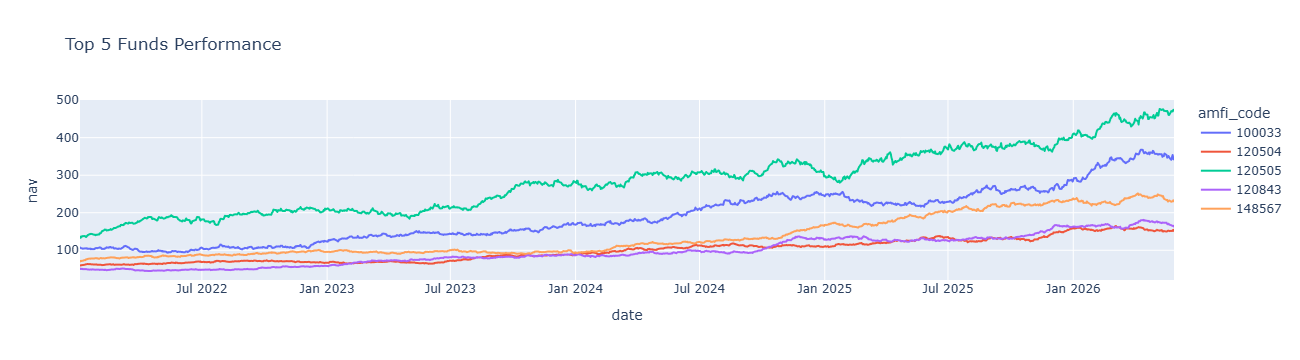

In [39]:
top5 = (
    scorecard.head(5)
    ["amfi_code"]
    .tolist()
)
comparison = nav[
    nav["amfi_code"].isin(top5)
]
fig = px.line(
    comparison,
    x="date",
    y="nav",
    color="amfi_code",
    title="Top 5 Funds Performance"
)

fig.show()

Top 5 Funds: [102886, 100016, 119095, 101207, 119092]


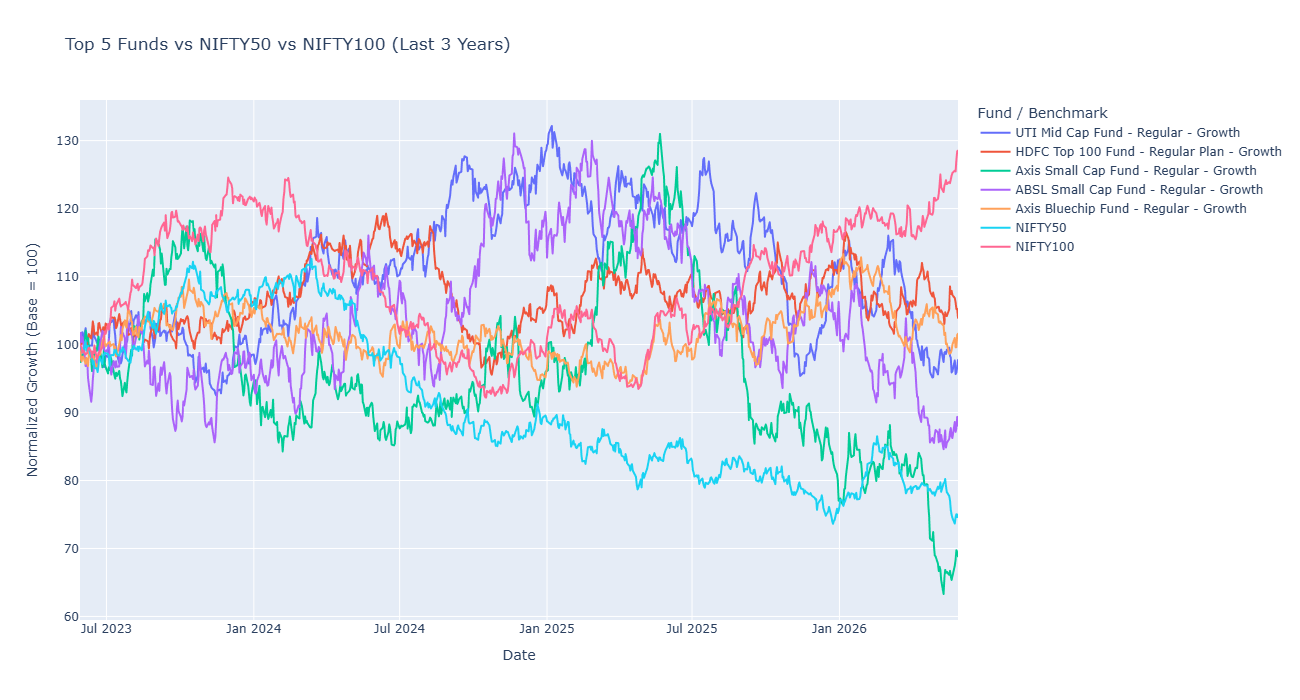

benchmark_comparison.png saved successfully


In [42]:

# ------------------------------------------------------------
# Get Top 5 Funds From Scorecard
# ------------------------------------------------------------

top5 = (
    scorecard
    .sort_values("fund_score")
    .head(5)["amfi_code"]
    .tolist()
)

print("Top 5 Funds:", top5)

# ------------------------------------------------------------
# Filter Last 3 Years
# ------------------------------------------------------------

latest_date = nav["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

nav_3y = nav[
    (nav["date"] >= start_date)
    &
    (nav["amfi_code"].isin(top5))
].copy()

# ------------------------------------------------------------
# Filter Benchmarks
# ------------------------------------------------------------

benchmark_3y = benchmark[
    benchmark["date"] >= start_date
].copy()

benchmark_3y = benchmark_3y[
    benchmark_3y["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
]

# ------------------------------------------------------------
# Normalize Funds (Base = 100)
# ------------------------------------------------------------

fund_frames = []

for code in top5:

    temp = nav_3y[
        nav_3y["amfi_code"] == code
    ].copy()

    temp = temp.sort_values("date")

    if len(temp) == 0:
        continue

    base_nav = temp["nav"].iloc[0]

    temp["normalized_value"] = (
        temp["nav"] / base_nav
    ) * 100

    scheme_name = funds.loc[
        funds["amfi_code"] == code,
        "scheme_name"
    ]

    if len(scheme_name) > 0:
        label = scheme_name.iloc[0]
    else:
        label = str(code)

    temp["series"] = label

    fund_frames.append(
        temp[
            ["date",
             "series",
             "normalized_value"]
        ]
    )

fund_plot = pd.concat(
    fund_frames,
    ignore_index=True
)

# ------------------------------------------------------------
# Normalize Benchmarks (Base = 100)
# ------------------------------------------------------------

benchmark_frames = []

for idx in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_3y[
        benchmark_3y["index_name"] == idx
    ].copy()

    temp = temp.sort_values("date")

    if len(temp) == 0:
        continue

    base_price = temp["close_value"].iloc[0]

    temp["normalized_value"] = (
        temp["close_value"] / base_price
    ) * 100

    temp["series"] = idx

    benchmark_frames.append(
        temp[
            ["date",
             "series",
             "normalized_value"]
        ]
    )

benchmark_plot = pd.concat(
    benchmark_frames,
    ignore_index=True
)

# ------------------------------------------------------------
# Combine Funds + Benchmarks
# ------------------------------------------------------------

plot_df = pd.concat(
    [fund_plot, benchmark_plot],
    ignore_index=True
)

# ------------------------------------------------------------
# Plot Comparison
# ------------------------------------------------------------

fig = px.line(
    plot_df,
    x="date",
    y="normalized_value",
    color="series",
    title="Top 5 Funds vs NIFTY50 vs NIFTY100 (Last 3 Years)"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Normalized Growth (Base = 100)",
    legend_title="Fund / Benchmark",
    height=700
)

fig.show()

# ------------------------------------------------------------
# Save Figure
# ------------------------------------------------------------

fig.write_image(
    "../reports/benchmark_comparison.png"
)

print("benchmark_comparison.png saved successfully")

# Section 13: Export Deliverables

In [23]:
cagr_df.to_csv(
    "../reports/performance/cagr_report.csv",
    index=False
)

alpha_beta_df.to_csv(
    "../reports/performance/alpha_beta.csv",
    index=False
)

scorecard.to_csv(
    "../reports/performance/fund_scorecard.csv",
    index=False
)